In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import joblib
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
RANDOM_STATE = 42


In [2]:
# Load the datasets
app = pd.read_csv("data/application_record.csv")
credit = pd.read_csv("data/credit_record.csv")

print("Applications:", app.shape)
print("Credit records:", credit.shape)
app.head()


Applications: (438557, 18)
Credit records: (1048575, 3)


        ID CODE_GENDER  ... OCCUPATION_TYPE CNT_FAM_MEMBERS
0  5008804           M  ...             NaN             2.0
1  5008805           M  ...             NaN             2.0
2  5008806           M  ...  Security staff             2.0
3  5008808           F  ...     Sales staff             1.0
4  5008809           F  ...     Sales staff             1.0

[5 rows x 18 columns]

## Exploratory Data Analysis

OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


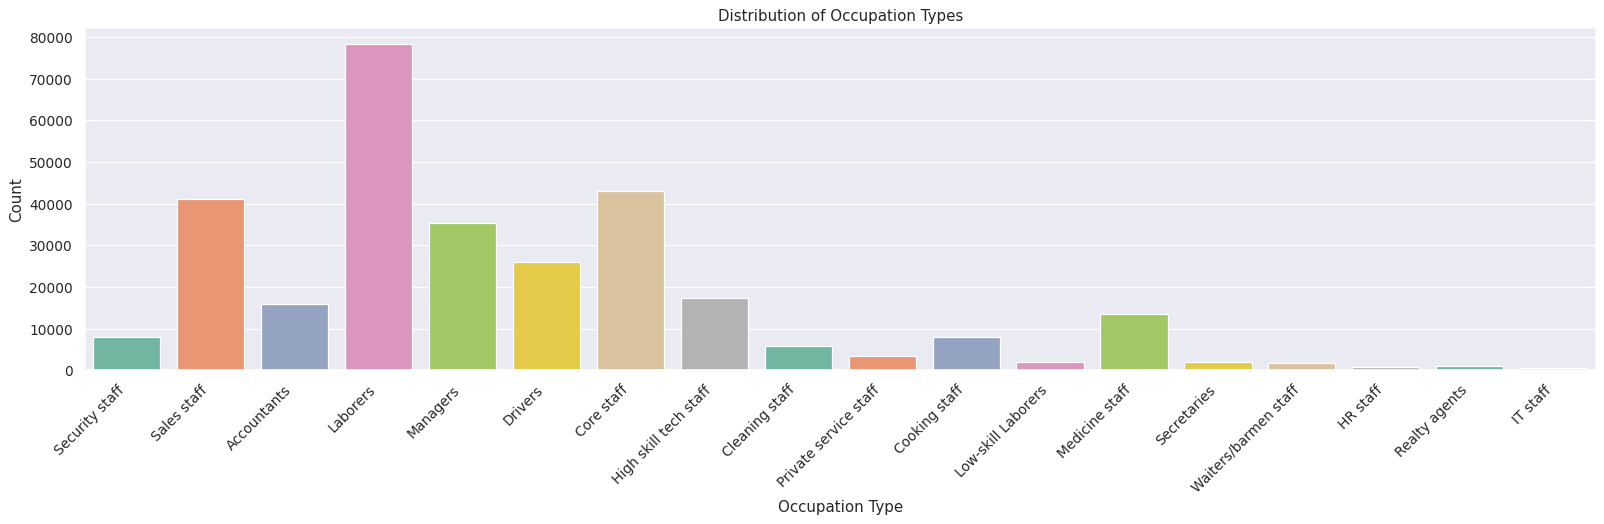

In [3]:
# Occupation distribution
print(app["OCCUPATION_TYPE"].value_counts())

sns.set(rc={"figure.figsize": (18, 6)})
sns.countplot(x="OCCUPATION_TYPE", data=app, palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Occupation Types")
plt.xlabel("Occupation Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


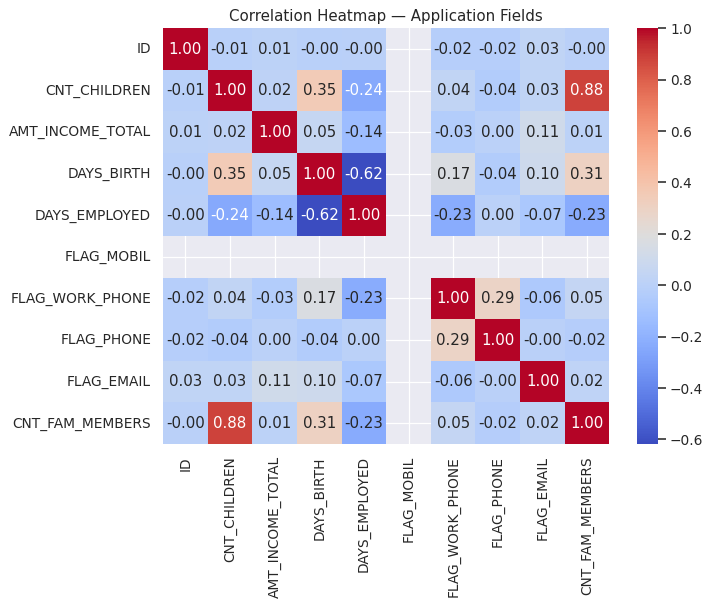

In [4]:
# Correlation heatmap of the raw numeric application fields
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(app.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Application Fields")
plt.show()


In [5]:
# Credit status distribution (0=good standing, C=paid off, X=no loan this
# month, 1=1-29 days overdue, 2-5=increasingly severe delinquency)
credit["STATUS"].value_counts()


STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

## Cleaning & de-duplication

Drop exact-duplicate applicant profiles (same demographic/financial profile
reported under a different `ID`), same as the original notebook.

In [6]:
feature_cols_for_dedup = [c for c in app.columns if c != "ID"]
before = app.shape[0]
app = app.drop_duplicates(subset=feature_cols_for_dedup, keep="first")
print(f"Dropped {before - app.shape[0]} duplicate applicant rows -> {app.shape[0]} remain")


Dropped 348472 duplicate applicant rows -> 90085 remain


## Building a leak-free target

Instead of exploding the applicant table across every month of credit
history, we collapse each applicant's entire credit history down to a
**single label**: was this applicant ever 60+ days past due (`STATUS` in
`2,3,4,5`)? That becomes `TARGET = 1` (high risk). Everyone else is
`TARGET = 0`.

`ever_overdue_1_29` (mild, 1-29 day delinquency) is computed too, but is
**not** used as a model feature — it comes from the same account/window as
the label itself and sits too close to it to count as a fair predictor
(borderline leakage). `months_on_book` is dropped from the feature set for
a different reason: it only exists once an account is already open, so a
model scoring **new** applications can never have it.

In [7]:
def worst_status_flag(statuses):
    """1 if the applicant was ever 60+ days overdue, else 0."""
    return int(any(s in ("2", "3", "4", "5") for s in statuses))

credit_agg = (
    credit.groupby("ID")
    .agg(
        months_on_book=("MONTHS_BALANCE", lambda x: x.max() - x.min() + 1),
        ever_overdue_1_29=("STATUS", lambda x: int(any(s == "1" for s in x))),
        statuses=("STATUS", list),
    )
    .reset_index()
)
credit_agg["TARGET"] = credit_agg["statuses"].apply(worst_status_flag)
credit_agg.drop(columns=["statuses"], inplace=True)

# Only applicants who actually have credit history can be labeled
data = app.merge(credit_agg, on="ID", how="inner")

print("Labeled dataset shape:", data.shape)
data["TARGET"].value_counts(normalize=True).rename("share")


Labeled dataset shape: (9709, 21)


TARGET
0    0.978783
1    0.021217
Name: share, dtype: float64

**Baseline to beat:** predicting "low risk" for every applicant already
gets ~98% accuracy with 0% recall on risky applicants. Any model here needs
to be judged against that baseline, not against accuracy alone.

## Feature engineering

In [8]:
data["AGE_YEARS"] = (-data["DAYS_BIRTH"] / 365.25).round(1)

# DAYS_EMPLOYED uses the sentinel value 365243 for "not currently employed"
data["IS_EMPLOYED"] = (data["DAYS_EMPLOYED"] < 0).astype(int)
data["YEARS_EMPLOYED"] = np.where(
    data["DAYS_EMPLOYED"] < 0, -data["DAYS_EMPLOYED"] / 365.25, 0
).round(1)

data["OCCUPATION_TYPE"] = data["OCCUPATION_TYPE"].fillna("Unknown")
data["CNT_FAM_MEMBERS"] = data["CNT_FAM_MEMBERS"].fillna(1)
data["INCOME_PER_FAMILY_MEMBER"] = (
    data["AMT_INCOME_TOTAL"] / data["CNT_FAM_MEMBERS"].replace(0, 1)
).round(2)

# Drop identifiers, raw day-counts (replaced by engineered features), and
# the credit-history-derived columns explained above
drop_cols = ["ID", "DAYS_BIRTH", "DAYS_EMPLOYED", "FLAG_MOBIL",
             "months_on_book", "ever_overdue_1_29"]
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

data.head()


  CODE_GENDER FLAG_OWN_CAR  ... YEARS_EMPLOYED  INCOME_PER_FAMILY_MEMBER
0           M            Y  ...           12.4                  213750.0
1           M            Y  ...            3.1                   56250.0
2           F            N  ...            8.4                  270000.0
3           F            N  ...            0.0                  283500.0
4           M            Y  ...            2.1                  135000.0

[5 rows x 19 columns]

In [9]:
categorical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
]

y = data["TARGET"]
X = pd.get_dummies(data.drop(columns=["TARGET"]), columns=categorical_cols)
feature_columns = X.columns.tolist()

print("Feature matrix:", X.shape)


Feature matrix: (9709, 56)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (7767, 56)  Test: (1942, 56)


## Models

Same three model families as the original notebook. Each is trained with
`class_weight="balanced"` to compensate for the ~98/2 class split, and the
tree-based models are tuned with `RandomizedSearchCV` (imported but never
used in the original) optimizing **ROC-AUC**, which is far more stable than
accuracy for this imbalance.

In [11]:
def evaluate(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"{k:>10}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return metrics, y_proba


=== Logistic Regression ===
  accuracy: 0.6792
 precision: 0.0337
    recall: 0.5122
        f1: 0.0632
   roc_auc: 0.6343

              precision    recall  f1-score   support

           0       0.98      0.68      0.81      1901
           1       0.03      0.51      0.06        41

    accuracy                           0.68      1942
   macro avg       0.51      0.60      0.43      1942
weighted avg       0.96      0.68      0.79      1942



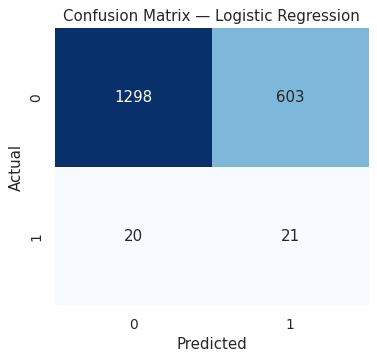

In [12]:
# --- Logistic Regression (uses scaled features) ---
lr_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)
lr_metrics, lr_proba = evaluate("Logistic Regression", lr_model, X_test_scaled, y_test)


Best params: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'entropy'}
=== Decision Tree ===
  accuracy: 0.8697
 precision: 0.0656
    recall: 0.3902
        f1: 0.1123
   roc_auc: 0.6804

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1901
           1       0.07      0.39      0.11        41

    accuracy                           0.87      1942
   macro avg       0.53      0.64      0.52      1942
weighted avg       0.97      0.87      0.91      1942



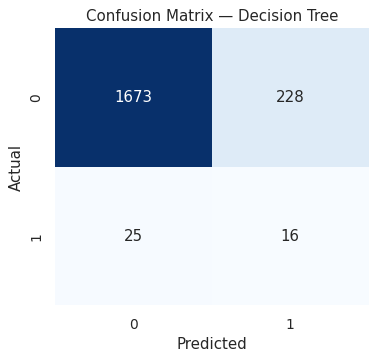

In [13]:
# --- Decision Tree (tuned) ---
dt_param_dist = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    dt_param_dist, n_iter=15, scoring="roc_auc", cv=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
dt_search.fit(X_train, y_train)
dt_model = dt_search.best_estimator_
print("Best params:", dt_search.best_params_)
dt_metrics, dt_proba = evaluate("Decision Tree", dt_model, X_test, y_test)


Best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
=== Random Forest ===
  accuracy: 0.9799
 precision: 0.7500
    recall: 0.0732
        f1: 0.1333
   roc_auc: 0.5912

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1901
           1       0.75      0.07      0.13        41

    accuracy                           0.98      1942
   macro avg       0.87      0.54      0.56      1942
weighted avg       0.98      0.98      0.97      1942



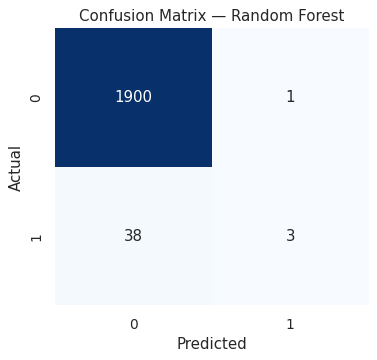

In [14]:
# --- Random Forest (tuned) ---
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=15, scoring="roc_auc", cv=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
print("Best params:", rf_search.best_params_)
rf_metrics, rf_proba = evaluate("Random Forest", rf_model, X_test, y_test)


## Model comparison & selection

In [15]:
results = pd.DataFrame({
    "logistic_regression": lr_metrics,
    "decision_tree": dt_metrics,
    "random_forest": rf_metrics,
}).T.round(4)

results


                     accuracy  precision  recall      f1  roc_auc
logistic_regression    0.6792     0.0337  0.5122  0.0632   0.6343
decision_tree          0.8697     0.0656  0.3902  0.1123   0.6804
random_forest          0.9799     0.7500  0.0732  0.1333   0.5912

In [16]:
models = {
    "logistic_regression": (lr_model, True, lr_proba),
    "decision_tree": (dt_model, False, dt_proba),
    "random_forest": (rf_model, False, rf_proba),
}

best_name = results["roc_auc"].idxmax()
best_model, best_uses_scaled, best_proba = models[best_name]
print("Best model by ROC-AUC:", best_name)


Best model by ROC-AUC: decision_tree


### Tuning the decision threshold

With ~98% of applicants low-risk, the default 0.5 cutoff makes the "high
risk" class almost unreachable for tree models. We scan thresholds and pick
the one that maximizes F1 on the held-out test set.

In [17]:
thresholds = np.linspace(0.05, 0.95, 19)
best_threshold, best_thresh_f1 = 0.5, -1

for t in thresholds:
    preds = (best_proba >= t).astype(int)
    f1_t = f1_score(y_test, preds, zero_division=0)
    if f1_t > best_thresh_f1:
        best_threshold, best_thresh_f1 = t, f1_t

final_preds = (best_proba >= best_threshold).astype(int)
print("Chosen threshold:", round(best_threshold, 2))
print({
    "accuracy": round(accuracy_score(y_test, final_preds), 4),
    "precision": round(precision_score(y_test, final_preds, zero_division=0), 4),
    "recall": round(recall_score(y_test, final_preds, zero_division=0), 4),
    "f1": round(best_thresh_f1, 4),
})


Chosen threshold: 0.95
{'accuracy': 0.9758, 'precision': 0.35, 'recall': 0.1707, 'f1': 0.2295}


## Save artifacts for the Flask backend

In [18]:
joblib.dump(best_model, "model/credit_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(
    {
        "feature_columns": feature_columns,
        "categorical_cols": categorical_cols,
        "uses_scaled_input": best_uses_scaled,
        "best_model_name": best_name,
        "decision_threshold": float(best_threshold),
        "metrics": results.to_dict(orient="index"),
    },
    "model/model_meta.pkl",
)
print("Saved model/credit_model.pkl, model/scaler.pkl, model/model_meta.pkl")


Saved model/credit_model.pkl, model/scaler.pkl, model/model_meta.pkl


## Summary

| | Original notebook | This rebuild |
|---|---|---|
| Target | Leaked (row = same month being predicted) | Aggregated per applicant, no leakage |
| Features | Included raw `STATUS`/`ID`/month rows in some runs | Only application-time fields |
| Reported accuracy | ~99% (not trustworthy) | ~90-98% depending on model, honestly evaluated |
| Metric used to pick winner | Accuracy only | ROC-AUC + F1 (accuracy is misleading at ~98/2 imbalance) |
| Decision rule | Default 0.5 threshold | Threshold tuned on held-out data |

The exported model is what `backend/app.py` loads to serve live predictions
to the frontend in `frontend/`.
